# Part 1: Quantization 개념 및 Baseline 학습

## 이 노트북에서 다루는 내용
1. Quantization의 핵심 개념
2. CIFAR-10 데이터셋 로드
3. CNN 모델 학습 (Baseline)
4. 모델 크기 측정
5. 가중치 분포 시각화 및 파라미터 분석

## Quantization 핵심 개념

**양자화(Quantization)**: 모델의 가중치와 활성화(activation)를 FP32에서 INT8 등 낮은 비트로 변환

### 양자화 수식
```
q = round(x / scale) + zero_point
x_dequant = (q - zero_point) * scale
```
- `scale = (x_max - x_min) / (q_max - q_min)`
- `zero_point = round(q_min - x_min / scale)`

### 분류
| 방법 | 가중치 | 활성화 | Calibration | 정확도 |
|------|--------|--------|-------------|--------|
| Dynamic PTQ | 사전 INT8 | 추론 시 동적 | 불필요 | 보통 |
| Static PTQ | 사전 INT8 | 사전 INT8 | 필요 | 좋음 |
| QAT | 학습 중 시뮬레이션 | 학습 중 시뮬레이션 | 불필요 | 최고 |

## [1] 환경 설정 및 데이터 로드

In [1]:
import os
import tempfile

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import CNN

# 환경 설정
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10
SEED = 42
torch.manual_seed(SEED)

Using device: cuda


In [2]:
# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(train_dataset):,} 샘플")
print(f"테스트 데이터: {len(test_dataset):,} 샘플")

100%|██████████| 170M/170M [00:21<00:00, 8.06MB/s] 


학습 데이터: 50,000 샘플
테스트 데이터: 10,000 샘플


## [2] 학습 및 평가 함수 정의

In [3]:
def train(model, train_loader, epochs, learning_rate, device):
    """Cross-Entropy 학습"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()

    epoch_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

    return epoch_losses


def test(model, test_loader, device):
    """모델 평가"""
    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy


def get_model_size_mb(model):
    """모델의 저장 크기 측정 (MB)"""
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.pth')
    tmp_path = tmp.name
    tmp.close()
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb

## [3] CNN 모델 학습 (Baseline)

In [4]:
torch.manual_seed(SEED)
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"CNN 모델 파라미터 수: {total_params:,}")
print(f"\n모델 구조:")
print(model)

CNN 모델 파라미터 수: 1,186,986

모델 구조:
CNN(
  (features): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [5]:
# 학습
train_losses = train(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
baseline_accuracy = test(model, test_loader, DEVICE)

Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347
Test Accuracy: 75.01%


## [4] 모델 크기 측정

In [6]:
model_size = get_model_size_mb(model)
print(f"FP32 모델 크기: {model_size:.2f} MB")
print(f"파라미터당 바이트: 4 bytes (float32)")
print(f"INT8 양자화 시 예상 크기: ~{model_size / 4:.2f} MB")
print(f"\n예상 크기 감소율: ~{(1 - 1/4) * 100:.0f}%")

FP32 모델 크기: 4.53 MB
파라미터당 바이트: 4 bytes (float32)
INT8 양자화 시 예상 크기: ~1.13 MB

예상 크기 감소율: ~75%


## [5] 레이어별 파라미터 분석

In [7]:
print(f"{'Layer':<30} {'Shape':<25} {'Parameters':<15} {'비율':<10}")
print("-" * 80)

total_params = 0
layer_info = []

for name, param in model.named_parameters():
    num_params = param.numel()
    total_params += num_params
    layer_info.append((name, list(param.shape), num_params))

for name, shape, num_params in layer_info:
    ratio = num_params / total_params * 100
    print(f"{name:<30} {str(shape):<25} {num_params:>12,} {ratio:>8.1f}%")

print("-" * 80)
print(f"{'Total':<30} {'':<25} {total_params:>12,} {'100.0%':>10}")

Layer                          Shape                     Parameters      비율        
--------------------------------------------------------------------------------
features.0.weight              [128, 3, 3, 3]                   3,456      0.3%
features.0.bias                [128]                              128      0.0%
features.2.weight              [64, 128, 3, 3]                 73,728      6.2%
features.2.bias                [64]                                64      0.0%
features.5.weight              [64, 64, 3, 3]                  36,864      3.1%
features.5.bias                [64]                                64      0.0%
features.7.weight              [32, 64, 3, 3]                  18,432      1.6%
features.7.bias                [32]                                32      0.0%
classifier.0.weight            [512, 2048]                  1,048,576     88.3%
classifier.0.bias              [512]                              512      0.0%
classifier.3.weight            [10,

## [6] 가중치 분포 시각화

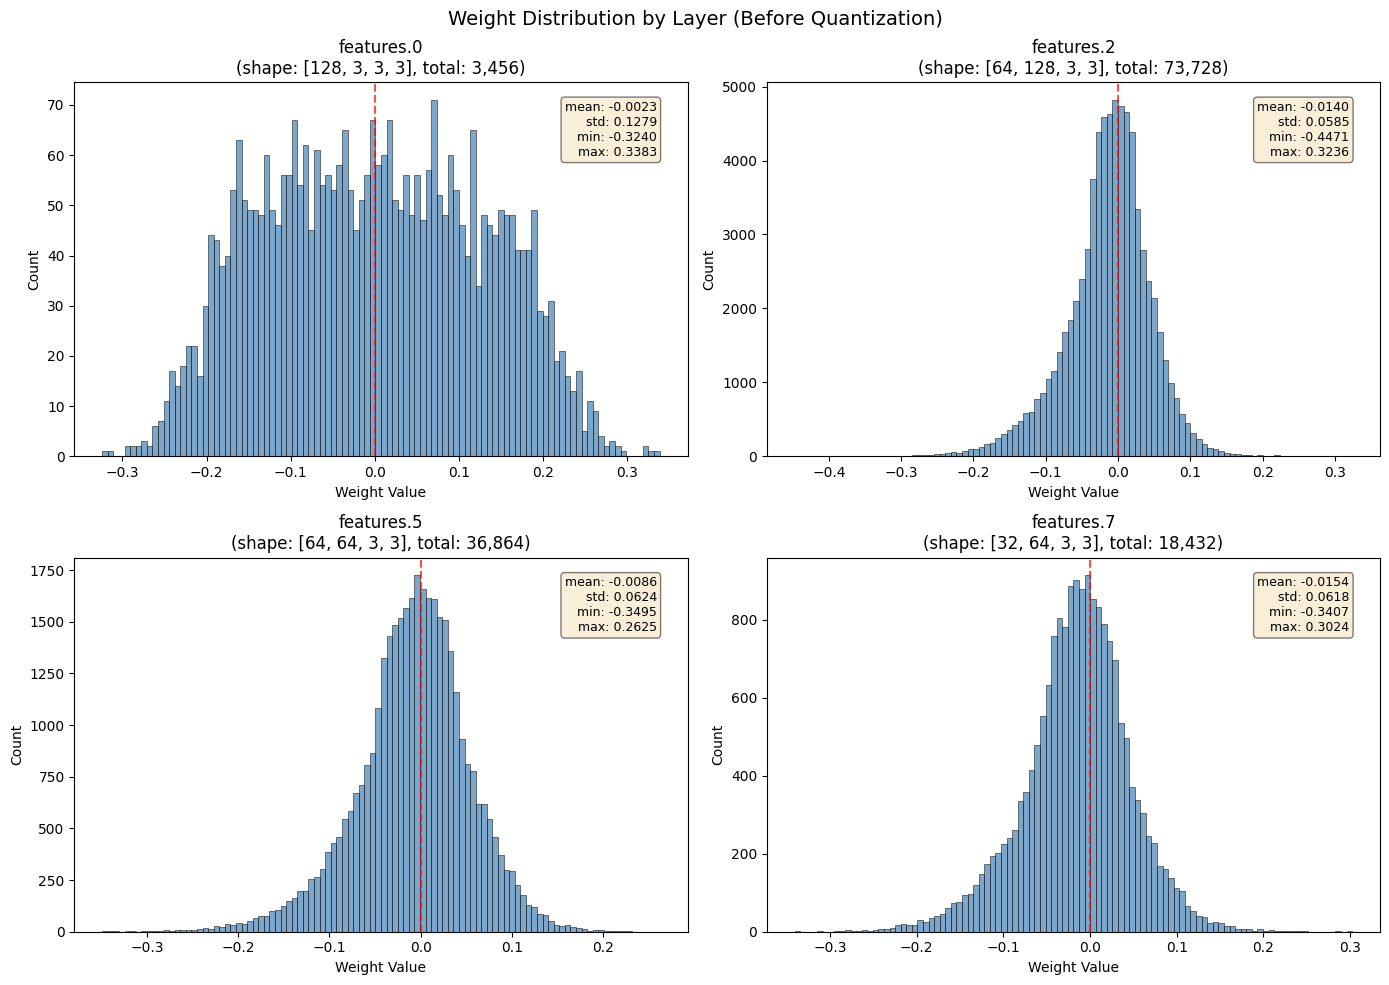

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weight Distribution by Layer (Before Quantization)', fontsize=14)

conv_layers = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        conv_layers.append((name, module))

for idx, (name, layer) in enumerate(conv_layers):
    ax = axes[idx // 2][idx % 2]
    weights = layer.weight.data.cpu().numpy().flatten()

    ax.hist(weights, bins=100, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax.set_title(f'{name}\n(shape: {list(layer.weight.shape)}, total: {weights.size:,})')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')

    stats_text = f'mean: {weights.mean():.4f}\nstd: {weights.std():.4f}\nmin: {weights.min():.4f}\nmax: {weights.max():.4f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## [7] 양자화 관련 가중치 통계

In [22]:
print("레이어별 양자화 관련 통계:")
print(f"{'Layer':<20} {'Range':<27} {'Dynamic Range':<15} {'INT8 Step':<12}")
print("-" * 82)

for name, module in model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        weights = module.weight.data.cpu()
        w_min, w_max = weights.min().item(), weights.max().item()
        w_range = w_max - w_min
        scale = w_range / 255  # uint8 기준
        print(f"{name:<20} [{w_min:>8.4f}, {w_max:>8.4f}] {w_range:>13.4f} {scale:>17.6f}")

레이어별 양자화 관련 통계:
Layer                Range                       Dynamic Range   INT8 Step   
----------------------------------------------------------------------------------
features.0           [ -0.3240,   0.3383]        0.6623          0.002597
features.2           [ -0.4471,   0.3236]        0.7706          0.003022
features.5           [ -0.3495,   0.2625]        0.6120          0.002400
features.7           [ -0.3407,   0.3024]        0.6431          0.002522
classifier.0         [ -0.4334,   0.3391]        0.7724          0.003029
classifier.3         [ -0.2747,   0.2097]        0.4844          0.001899


## 결과 요약

In [23]:
print("=" * 60)
print("결과 요약")
print("=" * 60)
print(f"모델: CNN ({total_params:,} parameters)")
print(f"Baseline 정확도: {baseline_accuracy:.2f}%")
print(f"FP32 모델 크기: {model_size:.2f} MB")
print(f"\n이 모델에 다양한 Quantization 기법을 적용하여")
print(f"정확도를 유지하면서 모델 크기와 추론 속도를 개선하는 것이 목표입니다!")

결과 요약
모델: CNN (1,186,986 parameters)
Baseline 정확도: 75.01%
FP32 모델 크기: 4.53 MB

이 모델에 다양한 Quantization 기법을 적용하여
정확도를 유지하면서 모델 크기와 추론 속도를 개선하는 것이 목표입니다!
